In [40]:

from pathlib import Path
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold, train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, roc_curve, precision_recall_curve, confusion_matrix
from tqdm import tqdm
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

In [41]:
SEED = 42
REPEATS = 5
FOLDS = 5

In [42]:
BASE_DIR = Path("../../data")
RAW_DIR = BASE_DIR / "raw" / "widsdatathon2025"
PROCESSED_DIR = BASE_DIR / "preprocessed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [43]:
# Load Data
train_cat = pd.read_excel(RAW_DIR / "TRAIN/TRAIN_CATEGORICAL_METADATA.xlsx")
train_fcm = pd.read_csv(RAW_DIR / "TRAIN/TRAIN_FUNCTIONAL_CONNECTOME_MATRICES.csv")
train_quant = pd.read_excel(RAW_DIR / "TRAIN/TRAIN_QUANTITATIVE_METADATA.xlsx")
train_solutions = pd.read_excel(RAW_DIR / "TRAIN/TRAINING_SOLUTIONS.xlsx")

test_cat = pd.read_excel(RAW_DIR / "TEST/TEST_CATEGORICAL.xlsx")
test_fcm = pd.read_csv(RAW_DIR / "TEST/TEST_FUNCTIONAL_CONNECTOME_MATRICES.csv")
test_quant = pd.read_excel(RAW_DIR / "TEST/TEST_QUANTITATIVE_METADATA.xlsx")

In [44]:
# Set index for participant id
for df in [train_cat, train_quant, train_fcm, test_cat, test_quant, test_fcm]:
    df.set_index("participant_id", inplace=True)

# merge all dataframes
train_data = train_cat.join(train_quant, how="left").join(train_fcm, how="left")
test_data = test_cat.join(test_quant, how="left").join(test_fcm, how="left")

In [45]:
# Dropping columns
drop_cols = [
    "Basic_Demos_Study_Site", "MRI_Track_Scan_Location", "PreInt_Demos_Fam_Child_Ethnicity",
    "PreInt_Demos_Fam_Child_Race", 'Barratt_Barratt_P1_Occ', 'Barratt_Barratt_P2_Occ'
]
train_data.drop(drop_cols, axis=1, inplace=True)
test_data.drop(drop_cols, axis=1, inplace=True)

In [46]:
# Impute values with mean and scale the data
# Note: try imputing with Lasso
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')), 
    ('scaler', MinMaxScaler()),
])

train_combined = pd.DataFrame(
    preprocessing_pipeline.fit_transform(train_data),
    columns=train_data.columns,
    index=train_data.index
)
test_combined = pd.DataFrame(
    preprocessing_pipeline.transform(test_data),
    columns=test_data.columns,
    index=test_data.index
)

In [47]:
# get y for ADHD and Sex (Train Solutions)
y_adhd = train_solutions.set_index("participant_id")["ADHD_Outcome"]
y_sex = train_solutions.set_index("participant_id")["Sex_F"]

connectome_data = pd.concat([train_fcm, test_fcm])


In [48]:
# Get connectome data for ADHD
merged_df_adhd = pd.merge(
    train_solutions[["participant_id", "ADHD_Outcome"]],
    connectome_data,
    on="participant_id",
    how="left"
)

# Drop participant_id column to keep only numeric columns
filtered_df_adhd = merged_df_adhd.drop(columns=["participant_id"])

# Calculate correlation with ADHD_Outcome
correlation_matrix_adhd = filtered_df_adhd.corr()["ADHD_Outcome"].drop("ADHD_Outcome")

# Extract top 100 features
top_100_features_adhd = correlation_matrix_adhd.abs().nlargest(100).index

# Prepare X and y
X_adhd = merged_df_adhd[top_100_features_adhd]
y_adhd_target = merged_df_adhd["ADHD_Outcome"]

# Train-test split
X_train_adhd, X_test_adhd, y_train_adhd, y_test_adhd = train_test_split(
    X_adhd, y_adhd_target, test_size=0.2, random_state=42, stratify=y_adhd_target
)

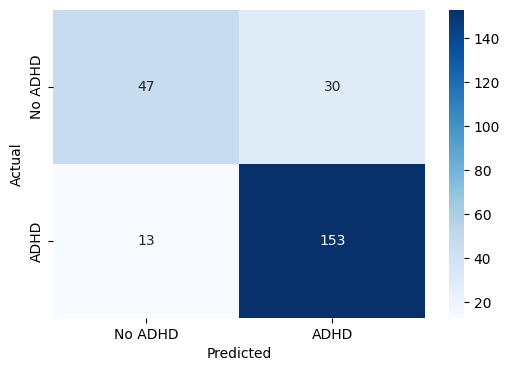

In [49]:

# Apply Logistic Regression

# Scale the data using Standard Scaler
scaler_adhd = StandardScaler()
X_train_scaled_adhd = scaler_adhd.fit_transform(X_train_adhd)
X_test_scaled_adhd = scaler_adhd.transform(X_test_adhd)

# Apply Logistic Regression
adhd_lr_model = LogisticRegression(max_iter=1000)
adhd_lr_model.fit(X_train_scaled_adhd, y_train_adhd)
y_pred_adhd = adhd_lr_model.predict(X_test_scaled_adhd)

# Plot confusion matrix to evaluate accuracy
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_adhd, y_pred_adhd), 
            annot=True, fmt='d', cmap="Blues",
            xticklabels=["No ADHD", "ADHD"], 
            yticklabels=["No ADHD", "ADHD"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [50]:
# Get connectome data for Sex
merged_df_sex = pd.merge(
    train_solutions[["participant_id", "Sex_F"]],
    connectome_data,
    on="participant_id",
    how="left"
)

# Drop participant_id column to keep only numeric columns
filtered_df_sex = merged_df_sex.drop(columns=["participant_id"])

# Calculate correlation with Sex_F
correlation_matrix_sex = filtered_df_sex.corr()["Sex_F"].drop("Sex_F")

# Extract top 100 features
top_100_features_sex = correlation_matrix_sex.abs().nlargest(100).index

# Prepare X and y
X_sex = merged_df_sex[top_100_features_sex]
y_sex_target = merged_df_sex["Sex_F"]

# Train-test split
X_train_sex, X_test_sex, y_train_sex, y_test_sex = train_test_split(
    X_sex, y_sex_target, test_size=0.2, random_state=42, stratify=y_sex_target
)

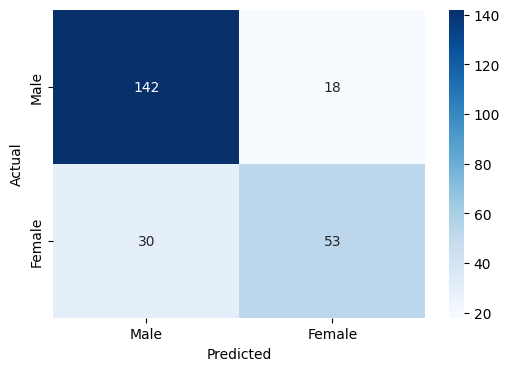

In [51]:
# Apply Logistic Regression
scaler_sex = StandardScaler()
X_train_scaled_sex = scaler_sex.fit_transform(X_train_sex)
X_test_scaled_sex = scaler_sex.transform(X_test_sex)

# Apply Logistic Regression
sex_lr_model = LogisticRegression(max_iter=1000)
sex_lr_model.fit(X_train_scaled_sex, y_train_sex)
y_pred_sex = sex_lr_model.predict(X_test_scaled_sex)

# Plot confusion matrix to evaluate accuracy
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_sex, y_pred_sex), 
            annot=True, fmt='d', cmap="Blues",
            xticklabels=["Male", "Female"], 
            yticklabels=["Male", "Female"])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [52]:
# Keep the features only relevant for Sex
features_sex = [
    'EHQ_EHQ_Total', 'ColorVision_CV_Score', 'APQ_P_APQ_P_CP', 'APQ_P_APQ_P_ID',
    'APQ_P_APQ_P_INV', 'APQ_P_APQ_P_OPD', 'APQ_P_APQ_P_PM', 'APQ_P_APQ_P_PP',
    'SDQ_SDQ_Conduct_Problems', 'SDQ_SDQ_Difficulties_Total', 'SDQ_SDQ_Emotional_Problems',
    'SDQ_SDQ_Externalizing', 'SDQ_SDQ_Generating_Impact', 'SDQ_SDQ_Hyperactivity',
    'SDQ_SDQ_Internalizing', 'SDQ_SDQ_Peer_Problems', 'SDQ_SDQ_Prosocial',
    'MRI_Track_Age_at_Scan', 'Barratt_Barratt_P1_Edu', 'Barratt_Barratt_P2_Edu'
] + top_100_features_sex.tolist()

# Keep features only relevant to ADHD
features_adhd = features_sex + top_100_features_adhd.tolist() + [
    'I_APQ_P_APQ_P_INV', 'I_APQ_P_APQ_P_PP', 'I_SDQ_SDQ_Hyperactivity',
    'I_MRI_Track_Age_at_Scan', 'I_SDQ_SDQ_Generating_Impact'
]

# Create interaction features (idk I just copied this from one of the other notebooks)
interactions = ["APQ_P_APQ_P_INV", "APQ_P_APQ_P_PP", "SDQ_SDQ_Hyperactivity", 
                "MRI_Track_Age_at_Scan", "SDQ_SDQ_Generating_Impact"]
for feature in interactions:
    train_combined[f'I_{feature}'] = train_combined[feature] * train_combined['MRI_Track_Age_at_Scan']
    test_combined[f'I_{feature}'] = test_combined[feature] * test_combined['MRI_Track_Age_at_Scan']


In [53]:
# Apply SMOTE to handle class imbalance
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(train_combined[features_sex], y_sex)

In [54]:
# Create final model for ADHD
model_adhd = XGBClassifier(
    n_estimators=500, learning_rate=0.03, max_depth=8,
    colsample_bytree=0.8, subsample=0.8, gamma=1,
    reg_lambda=10, reg_alpha=1, random_state=42
)

# Apply RepeatedStratifiedKFold
cv_adhd = RepeatedStratifiedKFold(n_splits=FOLDS, n_repeats=REPEATS, random_state=SEED)
adhd_scores = []
for train_idx, val_idx in tqdm(cv_adhd.split(train_combined, y_adhd), total=FOLDS*REPEATS):
    X_train, X_val = train_combined.iloc[train_idx], train_combined.iloc[val_idx]
    y_train, y_val = y_adhd.iloc[train_idx], y_adhd.iloc[val_idx]
    model_adhd.fit(X_train[features_adhd], y_train)
    adhd_scores.append(f1_score(y_val, model_adhd.predict(X_val[features_adhd])))

print(f"ADHD F1 Score: {np.mean(adhd_scores):.4f} ± {np.std(adhd_scores):.4f}")

100%|██████████| 25/25 [01:18<00:00,  3.15s/it]

ADHD F1 Score: 0.8796 ± 0.0155


In [61]:
# Re-run sex prediction with improved features and model
# Best Parameters: {'colsample_bytree': 0.6, 'gamma': 0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 500, 'reg_alpha': 1, 'reg_lambda': 0, 'subsample': 0.6}
best_params = {
    'colsample_bytree': 0.6,
    'gamma': 0,
    'learning_rate': 0.1,
    'max_depth': 7,
    'n_estimators': 500,
    'reg_alpha': 1,
    'reg_lambda': 0,
    'subsample': 0.6
}

# Initialize the XGBClassifier with the best parameters
model_sex = XGBClassifier(**best_params)


# Apply RepeatedStratifiedKFold 
cv_sex = RepeatedStratifiedKFold(n_splits=FOLDS, n_repeats=REPEATS, random_state=SEED)
sex_scores = []
for train_idx, val_idx in tqdm(cv_sex.split(train_combined, y_sex), total=FOLDS*REPEATS):
    X_train, X_val = train_combined.iloc[train_idx], train_combined.iloc[val_idx]
    y_train, y_val = y_sex.iloc[train_idx], y_sex.iloc[val_idx]
    model_sex.fit(X_train[features_sex], y_train)
    sex_scores.append(f1_score(y_val, model_sex.predict(X_val[features_sex])))

print(f"Sex F1 Score: {np.mean(sex_scores):.4f} ± {np.std(sex_scores):.4f}")

100%|██████████| 25/25 [00:38<00:00,  1.53s/it]

Sex F1 Score: 0.6477 ± 0.0536


Sex Thresholds: 100%|██████████| 100/100 [00:00<00:00, 916.32it/s]


Optimal ADHD Threshold: 0.556 (F1: 0.985)
Optimal Sex Threshold: 0.182 (F1: 0.947)


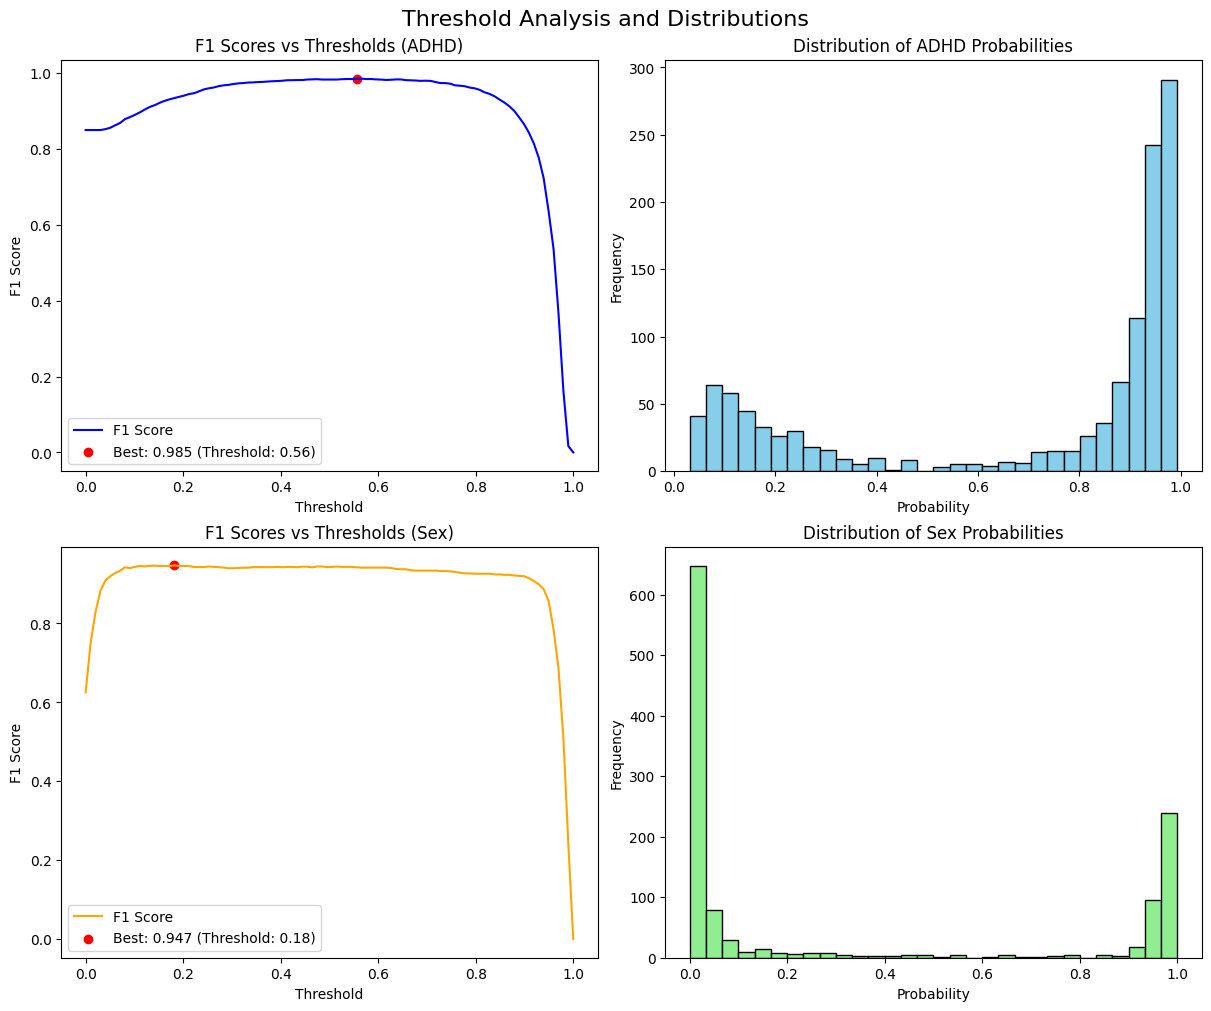

In [66]:
# Copied from https://www.kaggle.com/code/lennarthaupts/wids-predicting-adhd-in-women
adhd_probas = model_adhd.predict_proba(train_combined[features_adhd])[:, 1]  
sex_probas = model_sex.predict_proba(train_combined[features_sex])[:, 1]   

# Define weights based on y_adhd and y_sex
weights = ((y_adhd == 1) & (y_sex == 1)) + 1

thresholds = np.linspace(0, 1, 100)

# Compute F1 scores and find the best threshold for ADHD
adhd_scores = []
for t in tqdm(thresholds, desc="ADHD Thresholds"):
    tmp_pred = np.where(adhd_probas > t, 1, 0)
    tmp_score = f1_score(y_adhd, tmp_pred, sample_weight=weights)
    adhd_scores.append(tmp_score)
best_adhd_threshold = thresholds[np.argmax(adhd_scores)]
best_adhd_score = max(adhd_scores)

# Compute F1 scores and find the best threshold for Sex
sex_scores = []
for t in tqdm(thresholds, desc="Sex Thresholds"):
    tmp_pred = np.where(sex_probas > t, 1, 0)
    tmp_score = f1_score(y_sex, tmp_pred, sample_weight=weights)
    sex_scores.append(tmp_score)
best_sex_threshold = thresholds[np.argmax(sex_scores)]
best_sex_score = max(sex_scores)

print(f'Optimal ADHD Threshold: {best_adhd_threshold:.3f} (F1: {best_adhd_score:.3f})')
print(f'Optimal Sex Threshold: {best_sex_threshold:.3f} (F1: {best_sex_score:.3f})')

fig, axs = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)

# F1 scores for ADHD
axs[0, 0].plot(thresholds, adhd_scores, label='F1 Score', color='blue')
axs[0, 0].scatter(best_adhd_threshold, best_adhd_score, color='red', label=f'Best: {best_adhd_score:.3f} (Threshold: {best_adhd_threshold:.2f})')
axs[0, 0].set_title('F1 Scores vs Thresholds (ADHD)')
axs[0, 0].set_xlabel('Threshold')
axs[0, 0].set_ylabel('F1 Score')
axs[0, 0].legend()

# Histogram of ADHD probabilities
axs[0, 1].hist(adhd_probas, bins=30, color='skyblue', edgecolor='black')
axs[0, 1].set_title('Distribution of ADHD Probabilities')
axs[0, 1].set_xlabel('Probability')
axs[0, 1].set_ylabel('Frequency')

# F1 scores for Sex
axs[1, 0].plot(thresholds, sex_scores, label='F1 Score', color='orange')
axs[1, 0].scatter(best_sex_threshold, best_sex_score, color='red', label=f'Best: {best_sex_score:.3f} (Threshold: {best_sex_threshold:.2f})')
axs[1, 0].set_title('F1 Scores vs Thresholds (Sex)')
axs[1, 0].set_xlabel('Threshold')
axs[1, 0].set_ylabel('F1 Score')
axs[1, 0].legend()

# Histogram of Sex probabilities
axs[1, 1].hist(sex_probas, bins=30, color='lightgreen', edgecolor='black')
axs[1, 1].set_title('Distribution of Sex Probabilities')
axs[1, 1].set_xlabel('Probability')
axs[1, 1].set_ylabel('Frequency')

plt.suptitle('Threshold Analysis and Distributions', fontsize=16)
plt.show()

In [69]:
# Ensure predictions are added to test_combined
test_combined['adhd_proba'] = model_adhd.predict_proba(test_combined[features_adhd])[:, 1]
test_combined['sex_proba'] = model_sex.predict_proba(test_combined[features_sex])[:, 1]

# Apply optimal thresholds
test_combined['ADHD_Outcome'] = (test_combined['adhd_proba'] >= best_adhd_threshold).astype(int)
test_combined['Sex_F'] = (test_combined['sex_proba'] >= best_sex_threshold).astype(int)

# Create submission file
submission = test_combined[['ADHD_Outcome', 'Sex_F']].reset_index()
submission.columns = ['participant_id', 'ADHD_Outcome', 'Sex_F']
submission.to_csv(PROCESSED_DIR / "submission.csv", index=False)

print(f"Submission file saved to: {PROCESSED_DIR / 'submission.csv'}")

Submission file saved to: ../../data/preprocessed/submission.csv
